# Optimisation de portefeuille : version modulaire

Ce notebook est volontairement **léger et lisible**.
Toute la logique métier est dans `src/` : données, features, optimisation, ML et métriques.

Nous évaluons deux stratégies :
1. **Portefeuille Min Variance** sur les GAFAM
2. **Portefeuille Max Sharpe ML** sur GAFAM + actifs refuges (`GLD`, `TLT`)


## 1) Imports et paramètres globaux

Le notebook ne définit pas de fonctions complexes : il orchestre des appels aux modules Python.


In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_utils import (
    download_adj_close,
    compute_log_returns,
    get_daily_risk_free_rate,
    align_series_on_common_index,
)
from src.portfolio_optim import (
    backtest_min_variance,
    backtest_max_sharpe,
)
from src.ml_utils import fit_predict_xgb_multi_asset
from src.metrics import (
    performance_metrics,
    format_metrics_for_display,
    plot_cumulative_wealth,
)

plt.style.use("seaborn-v0_8")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Paramètres d'étude
TRADING_DAYS = 252
ROLLING_WINDOW = 60

START_DATE = "2015-01-01"
IN_SAMPLE_END = "2024-12-31"
OOS_START = "2025-01-01"
OOS_END = "2026-04-15"

GAFAM = ["AAPL", "AMZN", "GOOGL", "META", "MSFT"]
REFUGES = ["GLD", "TLT"]
UNIVERSE_ML = GAFAM + REFUGES
BENCHMARK = "^NDX"


## 2) Données de marché et rendements logarithmiques

On télécharge les prix ajustés, puis on passe en log-rendements pour travailler sur des séries plus adaptées aux modèles statistiques.


In [5]:
prices_gafam = download_adj_close(GAFAM + [BENCHMARK], START_DATE, OOS_END)
prices_assets_mv = prices_gafam[GAFAM].dropna()
prices_bench_mv = prices_gafam[BENCHMARK].dropna()

ret_assets_mv = compute_log_returns(prices_assets_mv)
ret_bench_mv = compute_log_returns(prices_bench_mv)
ret_assets_mv, ret_bench_mv = align_series_on_common_index(ret_assets_mv, ret_bench_mv)

rf_daily = get_daily_risk_free_rate(START_DATE, OOS_END, TRADING_DAYS)
rf_daily = rf_daily.reindex(ret_assets_mv.index).ffill().bfill()

print("Période commune:", ret_assets_mv.index.min().date(), "->", ret_assets_mv.index.max().date())
print("Observations GAFAM:", len(ret_assets_mv))


Période commune: 2015-01-05 -> 2026-04-14
Observations GAFAM: 2835


## 3) Baseline : portefeuille Min Variance (GAFAM uniquement)

- Covariance en fenêtre glissante (`Ledoit-Wolf`) via `src.portfolio_optim`
- Contraintes long-only (poids entre 0 et 1)
- Backtest Out-of-Sample 2025-2026


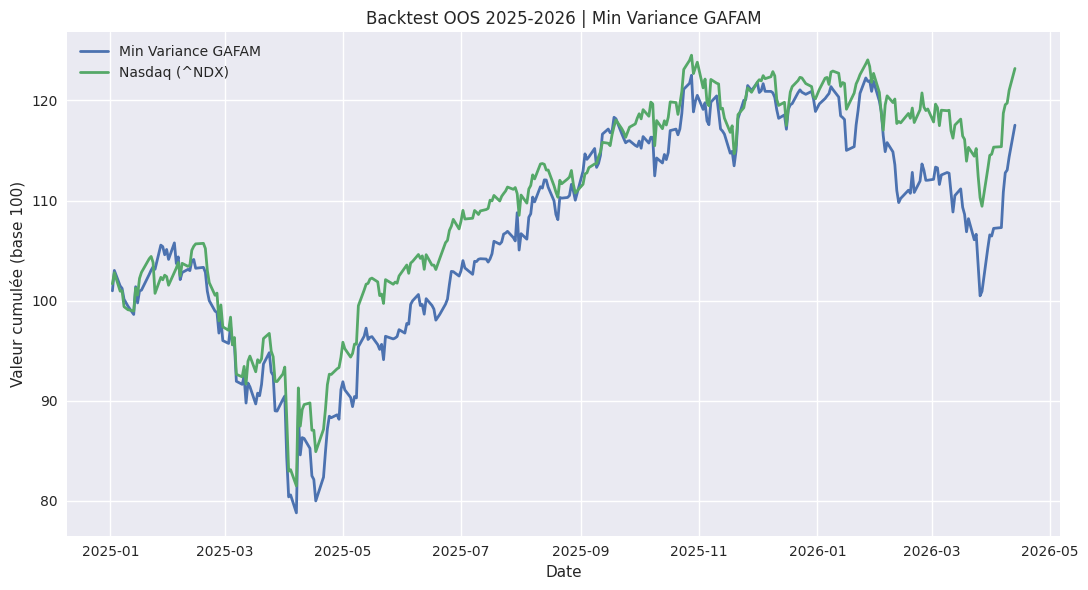

,Min Variance GAFAM,Nasdaq
Rendement annuel,13.61,17.92
Volatilité annuelle,24.81,22.53
Ratio de Sharpe,0.36,0.56
Max Drawdown,-25.51,-22.93
Alpha de Jensen,-3.66,-0.04


In [6]:
ret_port_mv, ret_bench_oos, weights_mv = backtest_min_variance(
    asset_returns=ret_assets_mv,
    benchmark_returns=ret_bench_mv,
    assets=GAFAM,
    oos_start=OOS_START,
    oos_end=OOS_END,
    rolling_window=ROLLING_WINDOW,
    bounds=(0.0, 1.0),
)

plot_cumulative_wealth(
    {
        "Min Variance GAFAM": ret_port_mv,
        "Nasdaq (^NDX)": ret_bench_oos,
    },
    title="Backtest OOS 2025-2026 | Min Variance GAFAM",
)

metrics_mv = pd.concat(
    [
        performance_metrics(ret_port_mv, ret_bench_oos, rf_daily.reindex(ret_port_mv.index), TRADING_DAYS).rename("Min Variance GAFAM"),
        performance_metrics(ret_bench_oos, ret_bench_oos, rf_daily.reindex(ret_port_mv.index), TRADING_DAYS).rename("Nasdaq"),
    ],
    axis=1,
)

display(format_metrics_for_display(metrics_mv).style.format("{:.2f}"))


## 4) Extension du modèle : Max Sharpe piloté par XGBoost

### Pourquoi cette extension ?

Le portefeuille Min Variance ne tient pas compte des rendements attendus. Ici, on prédit `μ` avec XGBoost puis on optimise le **ratio de Sharpe**.

### Feature Engineering

Pour chaque actif :
- lags (`1`, `3`, `5` jours),
- moyennes mobiles (`10`, `20` jours),
- volatilité glissante (`20` jours).

La cible est le rendement à `t+1`.


### Contrôle du data leakage

L'entraînement utilise `TimeSeriesSplit` (validation temporelle stricte) pour éviter toute fuite d'information et tout look-ahead bias.


In [7]:
prices_ml = download_adj_close(UNIVERSE_ML + [BENCHMARK], START_DATE, OOS_END)
prices_assets_ml = prices_ml[UNIVERSE_ML].dropna()
prices_bench_ml = prices_ml[BENCHMARK].dropna()

ret_assets_ml = compute_log_returns(prices_assets_ml)
ret_bench_ml = compute_log_returns(prices_bench_ml)
ret_assets_ml, ret_bench_ml = align_series_on_common_index(ret_assets_ml, ret_bench_ml)

rf_ml = rf_daily.reindex(ret_assets_ml.index).ffill().bfill()

mu_pred_oos, feature_importance_df, cv_table = fit_predict_xgb_multi_asset(
    returns_df=ret_assets_ml,
    assets=UNIVERSE_ML,
    in_sample_end=IN_SAMPLE_END,
    oos_start=OOS_START,
    oos_end=OOS_END,
    n_splits=5,
)

print("Qualité CV (RMSE):")
display(cv_table)


Qualité CV (RMSE):


,cv_rmse_mean,cv_rmse_std
asset,,
AAPL,0.0180,0.0043
AMZN,0.0209,0.0044
GLD,0.0089,0.0016
GOOGL,0.0188,0.0035
META,0.0250,0.0070
MSFT,0.0173,0.0044
TLT,0.0099,0.0023


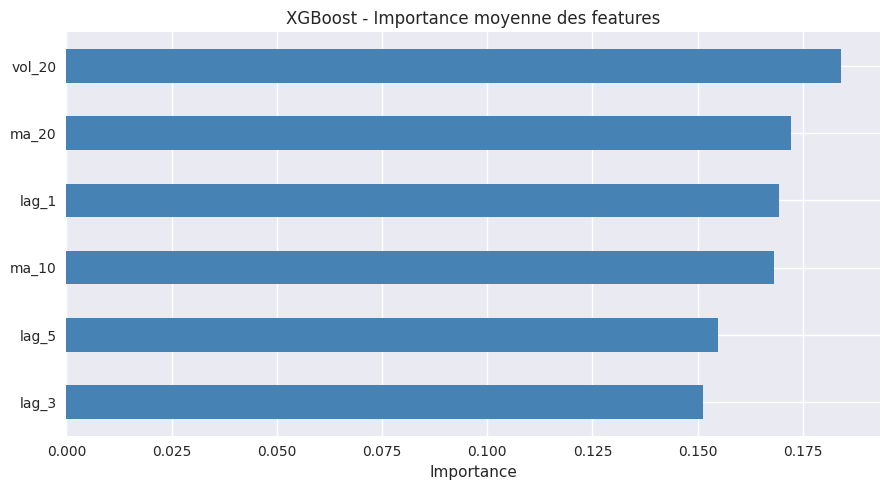

In [8]:
importance_mean = feature_importance_df.mean(axis=1).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
importance_mean.plot(kind="barh", color="steelblue")
plt.title("XGBoost - Importance moyenne des features")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [9]:
ret_port_ml, ret_bench_ml_oos, weights_ml = backtest_max_sharpe(
    asset_returns=ret_assets_ml,
    benchmark_returns=ret_bench_ml,
    mu_predictions=mu_pred_oos,
    risk_free_daily=rf_ml,
    assets=UNIVERSE_ML,
    rolling_window=ROLLING_WINDOW,
    bounds=(0.0, 1.0),
)


## 5) Comparaison finale des stratégies

On aligne les séries sur les mêmes dates pour une comparaison équitable.


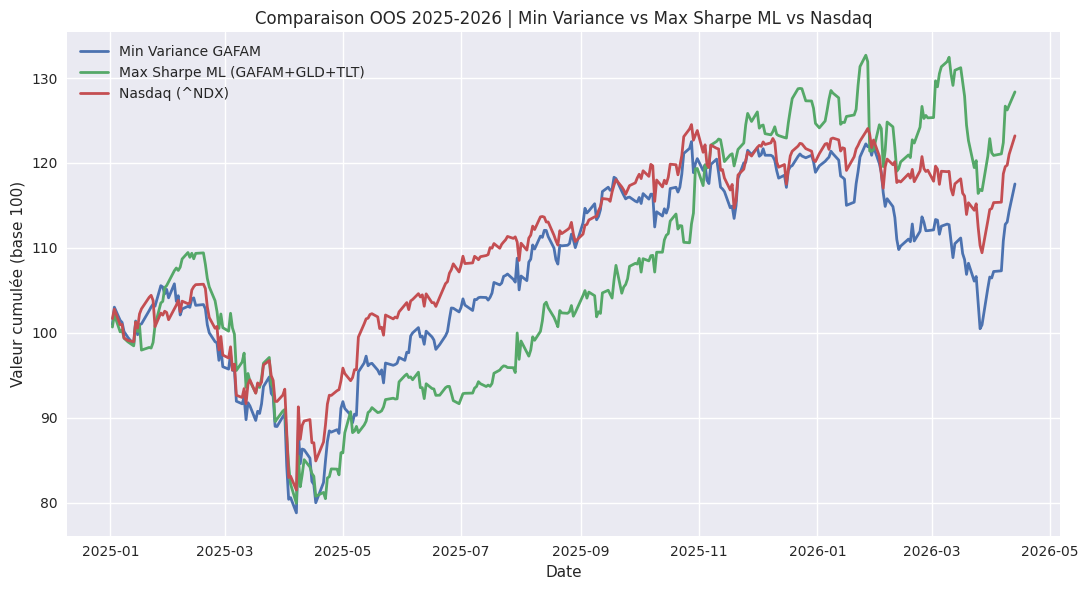

,Min Variance GAFAM,Max Sharpe ML,Nasdaq
Rendement annuel,13.61,21.81,17.92
Volatilité annuelle,24.81,24.35,22.53
Ratio de Sharpe,0.36,0.65,0.56
Max Drawdown,-25.51,-26.99,-22.93
Alpha de Jensen,-3.66,7.59,-0.04


Poids moyens Max Sharpe ML:


,Poids moyen
GLD,0.2049
MSFT,0.1647
AAPL,0.1591
META,0.1555
AMZN,0.1518
GOOGL,0.1011
TLT,0.0628


In [11]:
comparison = pd.concat(
    [
        ret_port_mv.rename("Min Variance GAFAM"),
        ret_port_ml.rename("Max Sharpe ML"),
        ret_bench_ml_oos.rename("Nasdaq"),
    ],
    axis=1,
).dropna()

ret_mv_cmp = comparison["Min Variance GAFAM"]
ret_ml_cmp = comparison["Max Sharpe ML"]
ret_bench_cmp = comparison["Nasdaq"]
rf_cmp = rf_ml.reindex(comparison.index)

plot_cumulative_wealth(
    {
        "Min Variance GAFAM": ret_mv_cmp,
        "Max Sharpe ML (GAFAM+GLD+TLT)": ret_ml_cmp,
        "Nasdaq (^NDX)": ret_bench_cmp,
    },
    title="Comparaison OOS 2025-2026 | Min Variance vs Max Sharpe ML vs Nasdaq",
)

metrics_final = pd.concat(
    [
        performance_metrics(ret_mv_cmp, ret_bench_cmp, rf_cmp, TRADING_DAYS).rename("Min Variance GAFAM"),
        performance_metrics(ret_ml_cmp, ret_bench_cmp, rf_cmp, TRADING_DAYS).rename("Max Sharpe ML"),
        performance_metrics(ret_bench_cmp, ret_bench_cmp, rf_cmp, TRADING_DAYS).rename("Nasdaq"),
    ],
    axis=1,
)

display(format_metrics_for_display(metrics_final).style.format("{:.2f}"))
print("Poids moyens Max Sharpe ML:")
display(weights_ml.mean().sort_values(ascending=False).to_frame("Poids moyen"))


## 6) Conclusion

Le notebook est désormais propre et maintenable :
- logique métier dans `src/`,
- narration pédagogique claire,
- séparation nette entre données, ML, optimisation et évaluation.
